# Systematic Macro 2026
### Carry · Momentum · Flow — Full Pipeline Demo

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from systematic_macro.data import MarketDataFetcher, EQUITY_UNIVERSE, FX_UNIVERSE
from systematic_macro.signals import CarrySignal, MomentumSignal, FlowSignal
from systematic_macro.portfolio import PortfolioOptimizer
from systematic_macro.backtest import WalkForwardEngine
from systematic_macro.utils import compute_sharpe, compute_max_drawdown, compute_icir

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.figsize': (14, 5), 'font.size': 11})
print('All imports OK ✓')

All imports OK ✓


## 1. Data — Synthetic 10-Year History (2015–2024)

In [2]:
TICKERS = ['SPY','EWJ','EWG','EWU','EWA','EWC','MCHI','EEM','EWZ','INDA']
fetcher = MarketDataFetcher()
prices = fetcher.fetch_prices(TICKERS, start='2015-01-02', end='2024-12-31', source='synthetic', seed=42)
returns = fetcher.compute_returns(prices)
fwd_returns = fetcher.compute_forward_returns(returns, horizon=21)  # 1-month ahead
print(f'Prices: {prices.shape} | Returns: {returns.shape}')
prices.tail(3)

Prices: (2608, 10) | Returns: (2607, 10)


,SPY,EWJ,EWG,EWU,EWA,EWC,MCHI,EEM,EWZ,INDA
2024-12-27,218.354681,316.434613,116.440180,356.778169,190.597514,68.264128,123.744184,162.662238,187.081566,316.522111
2024-12-30,217.482902,314.241983,118.182432,350.455251,192.956627,68.031715,123.679491,162.164453,187.534437,314.395240
2024-12-31,219.702595,317.571075,117.107333,352.726781,192.337310,68.075382,125.494077,161.159686,189.212615,315.804742


## 2. Signal Construction

In [3]:
# --- CARRY ---
div_yield = pd.DataFrame(0.02, index=prices.index, columns=TICKERS)
div_yield[['SPY','EWA']] = 0.035
div_yield[['MCHI','EEM','EWZ']] = 0.04
carry_sig = CarrySignal(vol_window=21)
carry = carry_sig.compute(prices, dividend_yield=div_yield)

# --- MOMENTUM ---
mom_sig = MomentumSignal(lookbacks=[21, 63, 126, 252])
momentum = mom_sig.compute(returns)

# --- FLOW (synthetic volume) ---
rng = np.random.default_rng(7)
volume = pd.DataFrame(rng.uniform(0.5, 1.5, prices.shape) * 1e6,
                      index=prices.index, columns=TICKERS)
flow_sig = FlowSignal(contrarian=True, contrarian_threshold=1.5)
flow = flow_sig.compute(prices, volume=volume)

print('Carry IC (tail):', carry.dropna().iloc[-252:].corrwith(fwd_returns.dropna().iloc[-252:]).mean().round(4))
print('Momentum IC (tail):', momentum.dropna().iloc[-252:].corrwith(fwd_returns.dropna().iloc[-252:]).mean().round(4))
print('Flow IC (tail):', flow.dropna().iloc[-252:].corrwith(fwd_returns.dropna().iloc[-252:]).mean().round(4))

2026-04-24 20:46:05.894 | DEBUG    | systematic_macro.signals.carry:_aggregate_carry:173 - Carry aggregated; shape=(2608, 10)


Carry IC (tail): 0.0426
Momentum IC (tail): -0.0089
Flow IC (tail): -0.0173


## 3. Portfolio Construction — Blended Signal

In [4]:
opt = PortfolioOptimizer(
    method='signal_scaled',
    target_vol=0.10,
    max_position=0.20,
    signal_weights={'carry': 0.33, 'momentum': 0.34, 'flow': 0.33}
)
composite = opt.blend_signals({'carry': carry, 'momentum': momentum, 'flow': flow})
weights = opt.compute_weights(composite.dropna(how='all'), returns)
weights_scaled = opt.vol_scale_weights(weights, returns)
port_ret = (weights_scaled.shift(1) * returns).sum(axis=1).dropna()
print(f'Portfolio | Sharpe: {compute_sharpe(port_ret):.3f} | MDD: {compute_max_drawdown(port_ret):.1%}')

2026-04-24 20:46:06.082 | INFO     | systematic_macro.portfolio.optimizer:blend_signals:162 - Blended 3 signals with weights {'carry': '0.33', 'momentum': '0.34', 'flow': '0.33'}


Portfolio | Sharpe: -0.168 | MDD: 28.2%


## 4. Walk-Forward Backtest

In [5]:
engine = WalkForwardEngine(
    is_years=5, oos_years=1, step_months=6,
    icir_threshold=0.3, sharpe_threshold=0.3,
    tc_bps=5.0, n_tests=3
)
result = engine.run(composite.dropna(how='all'), returns)
summary = result.summary()
print('=== Walk-Forward Summary ===')
for k, v in summary.items():
    print(f'  {k:20s}: {v:.4f}' if isinstance(v, float) else f'  {k:20s}: {v}')

2026-04-24 20:46:08.042 | INFO     | systematic_macro.backtest.engine:__post_init__:177 - Bonferroni-adjusted Sharpe threshold: 0.300 → 0.314 (3 tests)
2026-04-24 20:46:08.045 | INFO     | systematic_macro.backtest.engine:run:226 - Fold 1/9: IS 2015-01-09→2019-11-07 | OOS 2019-11-08→2020-10-26
2026-04-24 20:46:10.447 | DEBUG    | systematic_macro.utils.metrics:compute_rolling_ic:88 - Skipping 2019-11-07 00:00:00: only 0 valid observations.
2026-04-24 20:46:10.870 | DEBUG    | systematic_macro.utils.metrics:compute_rolling_ic:88 - Skipping 2020-10-26 00:00:00: only 0 valid observations.
2026-04-24 20:46:10.873 | INFO     | systematic_macro.backtest.engine:run:273 -   IS ICIR=0.002 | OOS ICIR=0.041 (≥0.3=False) | OOS Sharpe=1.285 (≥0.31=True) | MDD=0.018 (gate=False)
2026-04-24 20:46:10.874 | INFO     | systematic_macro.backtest.engine:run:226 - Fold 2/9: IS 2015-07-06→2020-05-01 | OOS 2020-05-04→2021-04-20
2026-04-24 20:46:12.897 | DEBUG    | systematic_macro.utils.metrics:compute_rolli

=== Walk-Forward Summary ===
  n_folds             : 9
  n_passed            : 0
  pass_rate           : 0.0000
  oos_sharpe          : 0.3120
  oos_mdd             : 0.0711
  oos_icir            : -0.0094
  is_icir_mean        : 0.0013
  is_icir_std         : 0.0101


## 5. Performance Visualisation

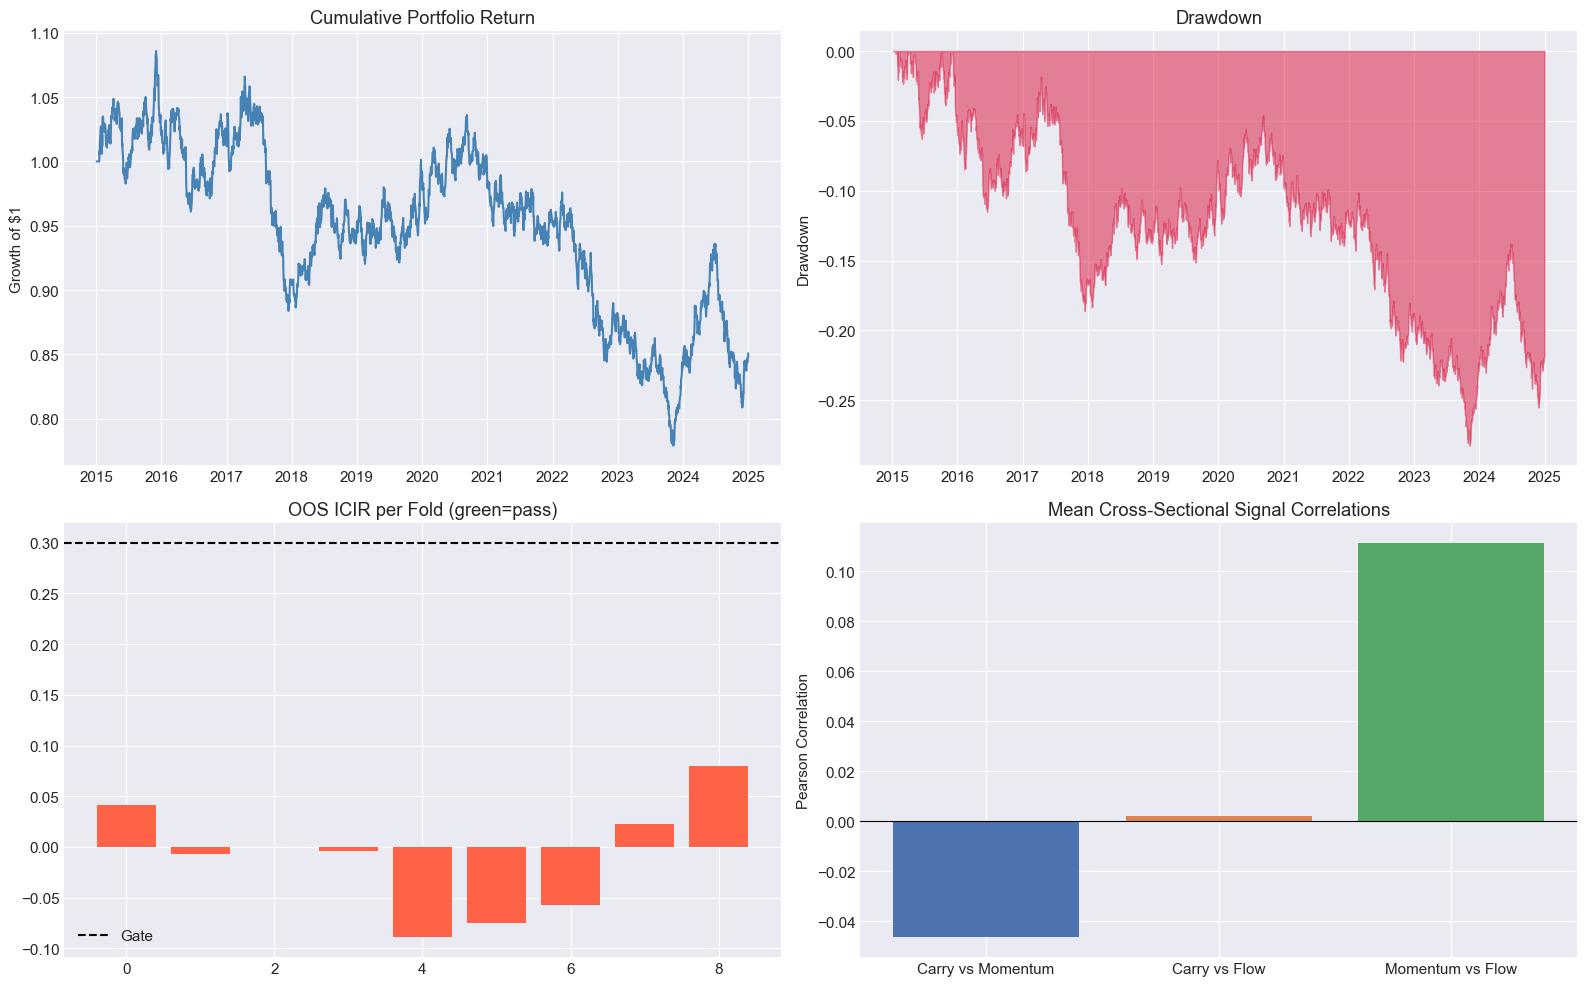

Dashboard saved.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Cumulative returns
cum = (1 + port_ret).cumprod()
axes[0,0].plot(cum.index, cum.values, color='steelblue', linewidth=1.5)
axes[0,0].set_title('Cumulative Portfolio Return')
axes[0,0].set_ylabel('Growth of $1')

# Drawdown
roll_max = cum.cummax()
dd = (cum - roll_max) / roll_max
axes[0,1].fill_between(dd.index, dd.values, 0, color='crimson', alpha=0.5)
axes[0,1].set_title('Drawdown')
axes[0,1].set_ylabel('Drawdown')

# OOS IC per fold
oos_ics = [f.oos_icir for f in result.folds]
colors = ['seagreen' if f.passed_gate else 'tomato' for f in result.folds]
axes[1,0].bar(range(len(oos_ics)), oos_ics, color=colors)
axes[1,0].axhline(engine.icir_threshold, linestyle='--', color='k', label='Gate')
axes[1,0].set_title('OOS ICIR per Fold (green=pass)')
axes[1,0].legend()

# Signal correlation heatmap
import seaborn as sns
common = carry.join(momentum, rsuffix='_mom').join(flow, rsuffix='_flow').dropna()
n = len(TICKERS)
sig_corr = pd.DataFrame({
    'Carry vs Momentum': [carry.corrwith(momentum, axis=1).mean()],
    'Carry vs Flow': [carry.corrwith(flow, axis=1).mean()],
    'Momentum vs Flow': [momentum.corrwith(flow, axis=1).mean()]
})
axes[1,1].bar(sig_corr.columns, sig_corr.values[0], color=['#4c72b0','#dd8452','#55a868'])
axes[1,1].axhline(0, color='k', linewidth=0.8)
axes[1,1].set_title('Mean Cross-Sectional Signal Correlations')
axes[1,1].set_ylabel('Pearson Correlation')

plt.tight_layout()
plt.savefig('performance_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('Dashboard saved.')

## 6. Stage 5 — Live Monitoring

In [7]:
if result.is_ic_baseline != 0.0:
    monitor = engine.monitor_live(
        composite.dropna(how='all'), returns,
        is_ic_baseline=result.is_ic_baseline,
        window=60, ratio_threshold=0.5
    )
    n_flags = monitor['flagged'].sum()
    print(f'Monitor: {n_flags} flag(s) over {len(monitor)} trading days')
    monitor[['rolling_ic','ic_ratio']].dropna().tail(20)
else:
    print('No passed folds — is_ic_baseline=0; skipping monitor.')

No passed folds — is_ic_baseline=0; skipping monitor.
